# Task b - Part 1
Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

In [18]:
#Cost data

year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}

costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]

In [19]:
# Cost Functions 

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity_values = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity_values + costs["FOM"] / 100) * costs["investment"]

In [20]:
# Load & Weather data
data_solar = pd.read_csv('data/pv_optimal.csv', sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv', sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

country = 'ESP'

In [21]:
# Task A
# Network Setup 
n = pypsa.Network()

hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')
n.set_snapshots(hours.values)

n.add("Bus", "Spain electricity")

n.add("Load",
      "demand",
      bus="Spain electricity",
      p_set=data_el[country].values)


In [22]:
# Generators

n.add("Generator", "CCGT",
      bus="Spain electricity",
      carrier="CCGT",
      capital_cost=costs.at["CCGT", "capital_cost"],
      marginal_cost=costs.at["CCGT", "marginal_cost"],
      efficiency=costs.at["CCGT", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=25300)

n.add("Generator", "coal",
      bus="Spain electricity",
      carrier="coal",
      capital_cost=costs.at["coal", "capital_cost"],
      marginal_cost=costs.at["coal", "marginal_cost"],
      efficiency=costs.at["coal", "efficiency"],
      p_nom_extendable=True,
      p_nom_max=11700)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add("Generator", "onwind",
      bus="Spain electricity",
      carrier="onwind",
      p_max_pu=CF_wind.values,
      capital_cost=costs.at["onwind", "capital_cost"],
      marginal_cost=costs.at["onwind", "marginal_cost"],
      efficiency=costs.at["onwind", "efficiency"],
      p_nom_extendable=True)

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add("Generator", "solar",
      bus="Spain electricity",
      carrier="solar",
      p_max_pu=CF_solar.values,
      capital_cost=costs.at["solar", "capital_cost"],
      marginal_cost=costs.at["solar", "marginal_cost"],
      efficiency=costs.at["solar", "efficiency"],
      p_nom_extendable=True)

In [23]:
# Fix & Optimize 
n.optimize(solver_name="highs")

print("\nOptimal capacities (GW):")
print(n.generators.p_nom_opt / 1000)

Index(['Spain electricity'], dtype='object', name='name')


Index(['CCGT', 'coal', 'onwind', 'solar'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 68.21it/s]
INFO:linopy.io: Writing time: 0.4s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78846 duals
Objective: 1.85e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Optimal capacities (GW):
name
CCGT      25.300000
coal      11.700000
onwind    70.337209
solar      7.242738
Name: p_nom_opt, dtype: float64


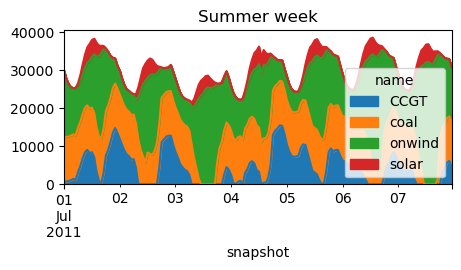

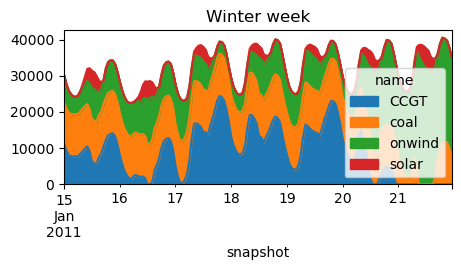

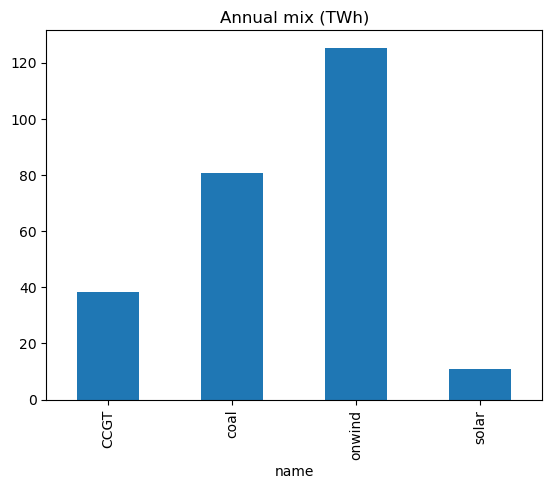

In [24]:
# Plot results

dispatch = n.generators_t.p

dispatch.loc["2011-07-01":"2011-07-07"].plot.area(figsize=(5, 2))
plt.title("Summer week")
plt.show()

dispatch.loc["2011-01-15":"2011-01-21"].plot.area(figsize=(5, 2))
plt.title("Winter week")
plt.show()

(dispatch.sum() / 1e6).plot(kind="bar")
plt.title("Annual mix (TWh)")
plt.show()

In [25]:
# Task B
# Setup Loop

simulation_years = range(1979, 2018)

capacity_results = pd.DataFrame(index=simulation_years,
                                columns=["CCGT", "coal", "onwind", "solar"])

load_2015 = data_el[data_el.index.year == 2015][country].values[:8760]


In [26]:
# Simulation Loop

for year in simulation_years:

    #print(f"Running year: {year}")

    n = pypsa.Network()

    snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="h")
    snapshots = snapshots[~((snapshots.month == 2) & (snapshots.day == 29))]
    n.set_snapshots(snapshots)

    n.add("Bus", "electricity bus")

    n.add("Load", "load",
          bus="electricity bus",
          p_set=load_2015)

    wind_year = data_wind[data_wind.index.year == year][country]
    solar_year = data_solar[data_solar.index.year == year][country]

    wind_year = wind_year[~((wind_year.index.month == 2) & (wind_year.index.day == 29))].values
    solar_year = solar_year[~((solar_year.index.month == 2) & (solar_year.index.day == 29))].values

    n.add("Generator", "CCGT",
          bus="electricity bus",
          carrier="CCGT",
          capital_cost=costs.at["CCGT", "capital_cost"],
          marginal_cost=costs.at["CCGT", "marginal_cost"],
          p_nom_extendable=True,
          p_nom_max=25300)

    n.add("Generator", "coal",
          bus="electricity bus",
          carrier="coal",
          capital_cost=costs.at["coal", "capital_cost"],
          marginal_cost=costs.at["coal", "marginal_cost"],
          p_nom_extendable=True,
          p_nom_max=11700)

    n.add("Generator", "onwind",
          bus="electricity bus",
          carrier="onwind",
          p_max_pu=wind_year,
          capital_cost=costs.at["onwind", "capital_cost"],
          marginal_cost=costs.at["onwind", "marginal_cost"],
          p_nom_extendable=True)

    n.add("Generator", "solar",
          bus="electricity bus",
          carrier="solar",
          p_max_pu=solar_year,
          capital_cost=costs.at["solar", "capital_cost"],
          marginal_cost=costs.at["solar", "marginal_cost"],
          p_nom_extendable=True)

    for df in [n.buses, n.loads, n.generators]:
        for col in df.columns:
            if "ArrowStringArray" in str(type(df[col].array)):
                df[col] = df[col].astype("object")

    n.optimize(solver_name="highs")

    capacity_results.loc[year] = n.generators.p_nom_opt / 1000


ValueError: Data for p_set has length 0 but expected 8760 for each snapshot.

In [ ]:
# Results

capacity_results = capacity_results.astype(float)

mean_capacity = capacity_results.mean()
std_capacity = capacity_results.std()

print("\nAverage capacities (GW):")
print(mean_capacity)

print("\nVariability (std dev, GW):")
print(std_capacity)

In [ ]:
# Final plot

plt.figure(figsize=(10, 6))

mean_capacity.plot(
    kind="bar",
    yerr=std_capacity,
    capsize=5
)

plt.title("Interannual variability")
plt.ylabel("Capacity (GW)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [ ]:
# New plot: Box plot

plt.figure(figsize=(10, 6))

capacity_results.plot(kind="box")

plt.title("Interannual variability of optimal capacities")
plt.ylabel("Capacity (GW)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()